## Unsupervised Learning:

Previously, we worked with problems and data samples that had labels, and the models we used relied on these labels to make predictions. However, in reality, most available data is unlabeled—we do not know their categories, only some of their features. To analyze such data, we use **Unsupervised Learning** approaches.

+ **Definition:**

    Unsupervised learning involves analyzing unlabeled data to discover hidden patterns or structures within the data. And it helps us to be able to use data that have not been labeled.

> In problems that get solved using unsupervised learning approaches labeling the data we've got is the high-cost part of the procedure of learning.

**Common clustering tasks and problems that we deal with**:

+ **Clustering**: Grouping data points into clusters based on similarity
+ **Dimension Reduction**: Reducing the number of features under consideration and keeping (almost approximately) the most informative features.
+ **Anomaly Detection**: Identifying data pints that deviate significantly from norm (e.g., fraud detection, alerts(could be any one of them that has happened based on an unregulairty))
+ **Generative Modeling**: Learning the **distribution** of data to generate new, similar instances.

`In this notebook we want to dig into clustering`

## Clustering

Clustering is an unsupervised ML algorithm that **organizes** and **classifies** different objects, data points, or observations into groups or clusters based on similarities or patterns.

> "The notion of similarity depends on the task at hand (e.g., purchase behavior in market segmentation)."

**Real-life applications of clustering include:**
- Customer segmentation in marketing
- Image segmentation in computer vision
- Document or news article categorization
- Anomaly detection in network security
- Grouping genes with similar expression patterns in bioinformatics
- Recommender systems (grouping users/items by behavior)
- Social network analysis (community detection)
- Organizing large datasets for efficient retrieval and analysis


We have many different types of clustering as there are multiple ways to define a cluster. Different approaches will work well for different types of models depending on the size of the input data, the dimensionality of the data, the rigidity of the categories and the number of clusters within the dataset, It's worth noting that one algorithm may work very well for one dataset and very poorly on another:

+ **Centroid-based clustering**
+ **Hierarchial clustering**
+ **Distribution-based clustering**
+ **Density-based clustering**
+ **Grid-based clustering**


Now what we should do is to find a way for the two problems below:

+ How to create a good cluster?
+ How many  clusters do we need?

### K-Means:

K-Means is one of the most common used centroid-based clustering algorithms. In this technique, K-Means assumes that the **center** of each cluster defines the cluster Using a distance measure, mostly commonly Euclidean distance, to the centroid.<br>
It's purpose is to partition data into *K* distinct clusters based on the features **similarity**.<br>
How it works is basically like this: We choose some random cnetroids as the center of our *K* clusters and then **Iteratively** assign data points to the nearest centroid (means of the group) and then recalculate the centroid based on the new group memberships. The process repeats until the assignments no longer change.

It's algorithm:

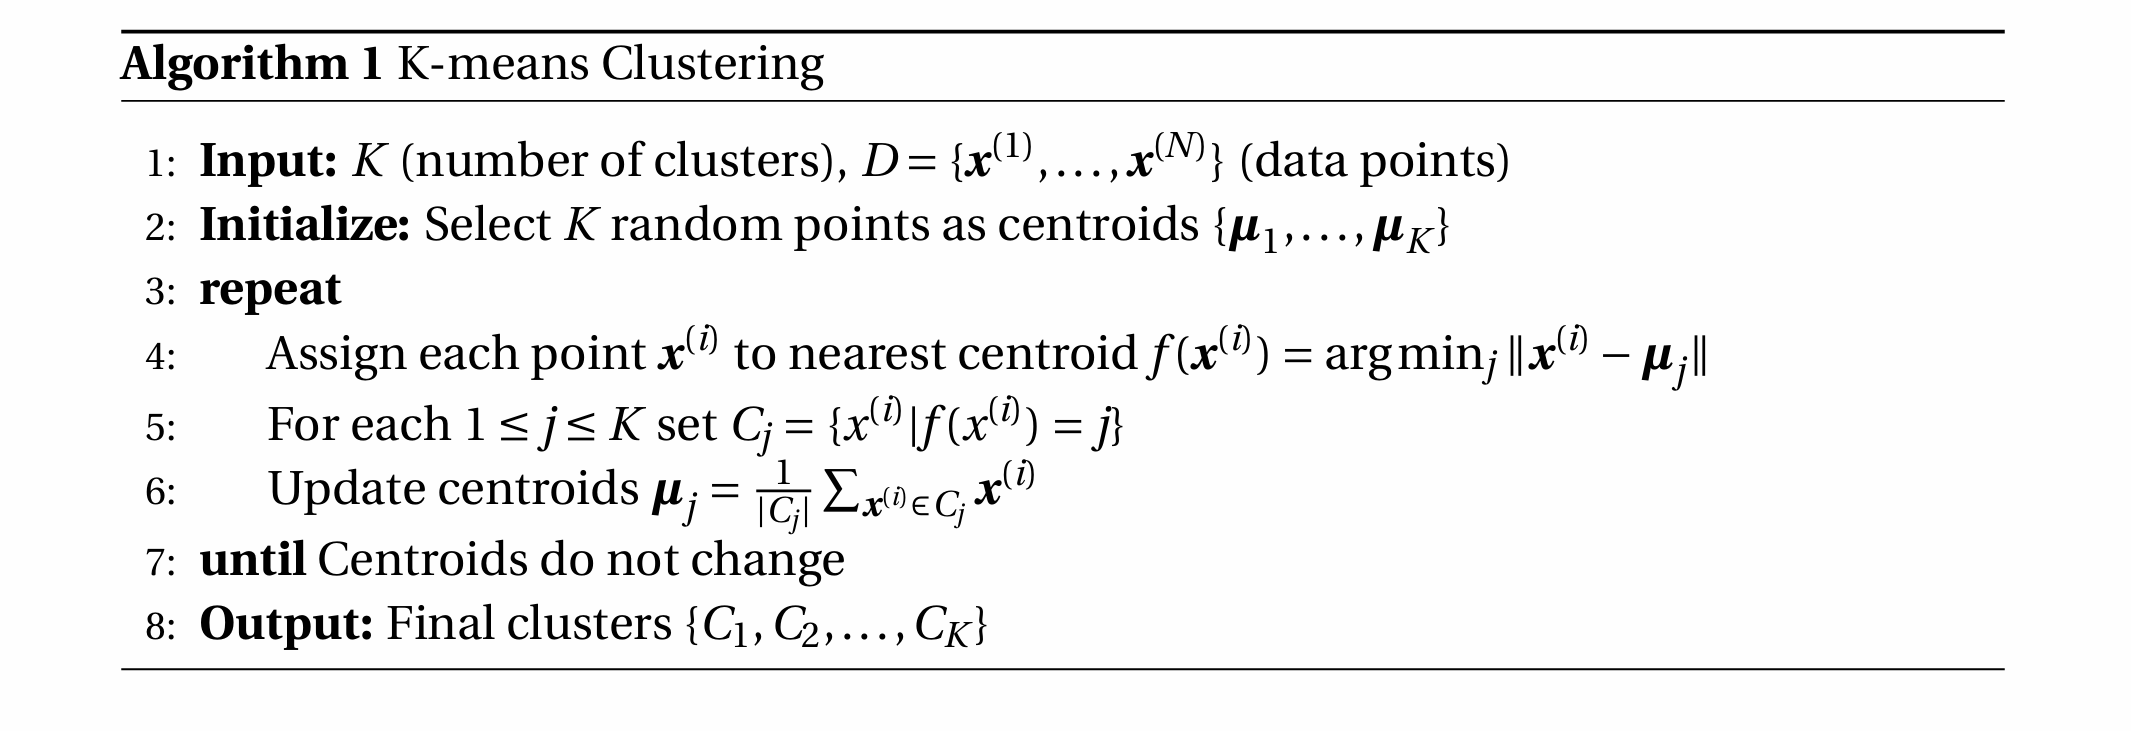
<center>Figure 1: K-Means algorithm, Adopted from [2]</center>
<br>

So we have a train dataset:

$$X_{train} = \{x^{(1)}, x^{(2)}, ..., x^{(N)}\} \subseteq R^d$$

And we've got a $K$ which is the number of the clusters.

What we're learning:
1. A function or a mapping: $f: R^d \rightarrow \{1, 2, ..., K\}$ that assigns a cluster to each data point.
2. A set of $K$ prototypes $\mu = \{\mu_1, \mu_2, ..., \mu_K\} \subseteq R^d$ as the cluster representatives, called **Centeroids**

> Our purpose is to create segmentation of data points in clusters such that that segmentation be optimal.

We have bunch of data points and we wanna segment them into clusters 1, 2, ...., k such that the sum of data point's distance from their cluster's centroid to be the minimum value possible. 

The proposition above gets formulzed as the formula below which is kind of the cost function of K-Means and we wanna minimize it:

$$J = \sum_{j=1}^{K} \sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j||^2$$

So we have to choose an $f$ (mapping) and $\mu = \{\mu_1, \mu_2, ..., \mu_k\}$ such that the equation above gets optimal(minimum value possible).

The thing we want in simple terms is that we want to assing data points to clusters such that the function $J$ gets minimum. But this is an **NP-hard** problem which means that there's no polynomial algorithm for (at least yet) that guarantees to give us the optimal solution.<br>

So K-Means will not necessarily result the optimal solution. And we can say that K-Means is a heuristic algorithm, and it may stuck in a local optimum and do not result in global optimum.

+ So the question here is that does K-Means get converge? and by *converge* we mean that does it get out of the optimization loop and reach to a minimum in it's algorithm or it will stuck in the loop forever?

> The answer to the question above is YES. In the below section we're gonna see why.

#### Convergence:

Earlier we defined a function $J$ which  is the sum of the distnaces of each samples to it's cluster's centroid, and we wanna prove taht teh $J$ function decreases every time that the update loop of K-Means algorithm runs and it cannot get lower than zero and have infinite number of conditions.<br>

+ Something we have to prove first is that the $J$ will have infinite numbers of values/states given a finite set:

    If we were given any amount of data, They're assignment to each cluster has finite states, meaning that when we wanna add a data point to a one of our clusters, knowing we have `K` clusters, has `K` states that data ponint can get add to, So having *N* data points makes the states and conditions possible for assigning data points to cluster less than equal to $K^N$. So states cannot have more than $K^N$ **permutation** in the feature space we're having so we can conclude from that the number of valeus possible for the $J$ also cannot exceed $K^N$.<br>
    So we draw conclusion from this that if $J$ decreases in the algorithm, in a finite set, it will get to a minimum and comes out of the loop and the algorithm ends.


Now let's get to the proof of that $J$ decreases after each iteration of the algorithm's loop.<br>
There are two way of proving the convergence of K-Means algorithm:

1. **Proof 1(Descriptive proof)**:

+ So initially we have some random centroid and we assign each sapmple to the nearest centroid:

$$f(x):=\argmin_{j} ||x - \mu_j||^2$$
<center>Adopted from [2]</center>

Then we keep each sample's assignment **fixed** until a **closer** centroid is found. This doesn't apply to equal distance, if in moving centroids the distance of a sample get equal between two centroids, it's centroid and cluster would not change, otherwise if the sample find a distance to a centroid which is smaller than it's previous distance to another centroid, it will change clusters and according to the formula of $J$ we have now seen a decrease in distance and this will lead to decrease of $J$.

+ Each time a sample is reassigned. The **total distance** between samples and their centroid **decreases** .
+ The number of possible sample-to-centroid assignment is finite(have been proved above)
+ And the algorithm terminates when no sample changes its assigned centroid.


2. **Proof 2(Mathematical proof)**

+ In updating step, with mapping function $f(x)$ being fixed, $J$ is a quadratic function of $\mu_j$ (like SSE) and by taking derivative we can minimize it as:

$$\frac{\partial J}{\partial \mu_j} = \sum_{x^{(i)} \in C_j} 2(x^{(i)} - \mu_j) = 0$$

+ This means that we should **update** each $\mu_j$ as the mean of cluster $C_j$:

    $$\mu_j = \frac{\sum_{x^{(i)} \in C_j} x^{(i)}}{|C_j|}$$

    + $|C_j|$: number of cluster's samples(cause $\mu_j$ is being repeated to the number of cluster's samples)
 
> The above equation is saying that the sample that is goign to make the cost function minimum is the mean of the samples of a cluster(for each cluster obviously)

+ For each cluster, the mean of its samples minimizes squared distance.
+ For $C_j$ if $\mu_j'$ was the old centroid we have: $\sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j'||^2 \geq \sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j||^2$. So $J_{new} \leq J_{old}$


The thing we're telling is:

The centroid or $\mu$ of each cluster in the process of algorithm changes, and we have proven that if $\mu$ was the previous centroid of the cluster and $\mu'$ is the new centroid of the cluster due to the mean of the cluster's samples after update in the algorithm's loop.<br>
We have proven that the sum of the cluster's sample's distance with new centroid $\mu'$ is smaller than the cluster's sample's distance with the previous centroid $\mu$. This means the convergence of $J$ .

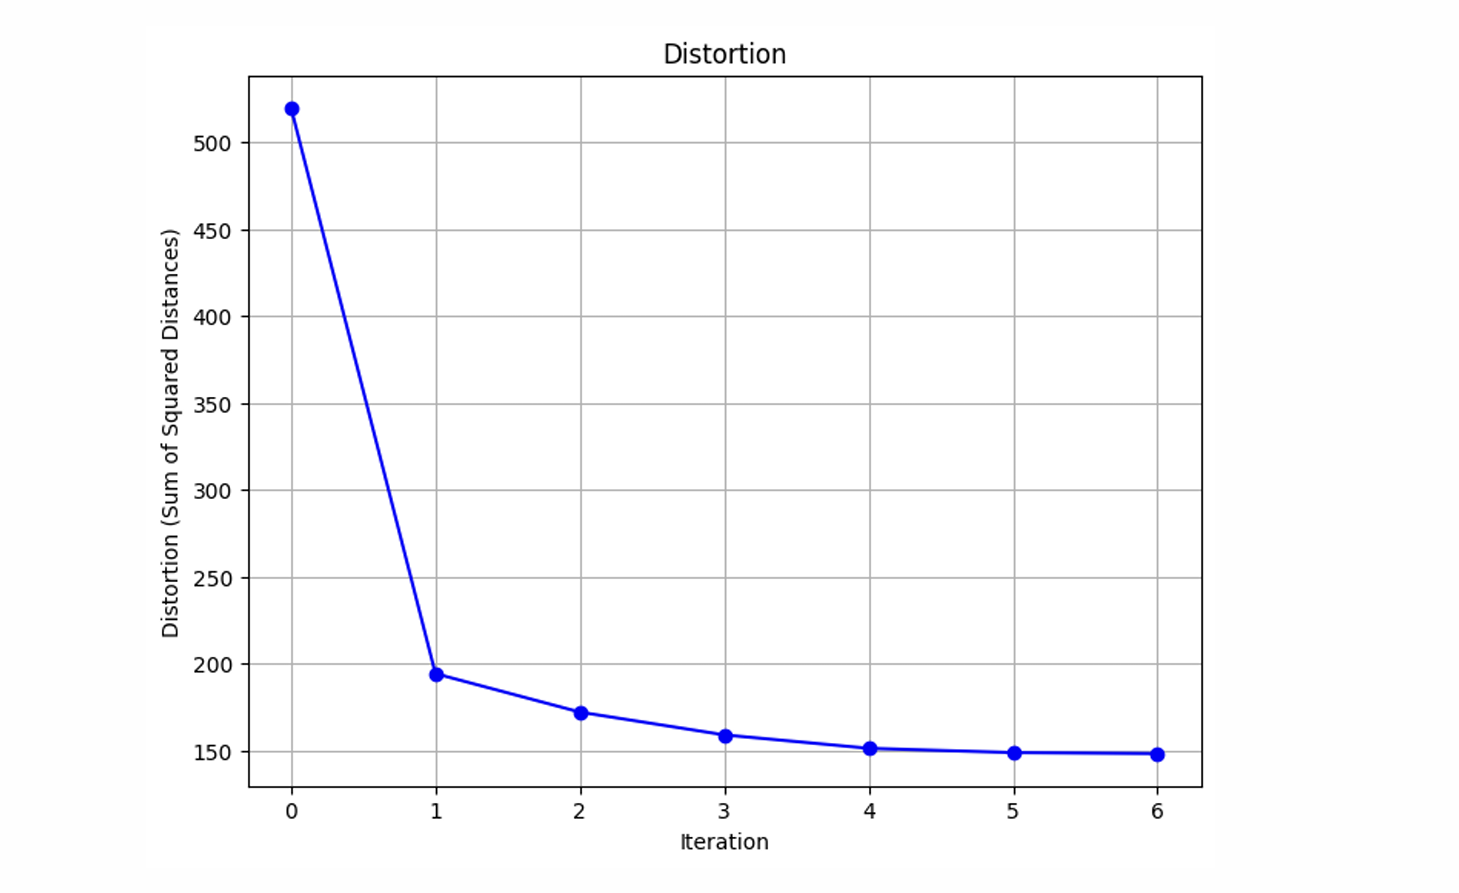
<center>Figure 2: Distortion's convergence, Adopted from [2]</center>

### References:

[1] [Clustering, IBM](https://www.ibm.com/think/topics/clustering)<br>
[2] [Kmeans slide, ML course, sharif university](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Slides/Chapter_02_Unsupervised_Learning/01-Clustering/02-01-KMeans.pdf)<br>
[3] []()<br>
[4] []()<br>
